# Rental Revenue Model — Madrid & Barcelona (v1)

Predicts **gross monthly rent (EUR)** for residential listings, the rental arm of the
*rent vs. Airbnb vs. sell* decision system. Annual revenue = monthly x 12.

**Data:** idealista rental scrape (~Sept 2022), Madrid & Barcelona city proper, deduplicated and
cleaned to **2,595 listings**. Location is parsed from the structured `title` field — the engineered
**neighbourhood** turns out to be the #2 predictor.

**Approach (balanced):** interpretable Ridge baseline + XGBoost, compared on a held-out test set.
**Known limitation:** 2022 vintage + thin features (no bathrooms/amenities) → target MAPE ~20-30%.


In [1]:
import sys, warnings; sys.path.append("../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from features import build_model_frame
from model import train_and_evaluate, predict_rent, FEATURES
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
FIG = "../reports/figures"; import os; os.makedirs(FIG, exist_ok=True)

## 1. The modelling frame & engineered location features

In [2]:
df = build_model_frame(scope="city", verbose=False)
print("shape:", df.shape)
df.head()

shape: (2595, 8)


,rent_eur_month,city,municipality,neighborhood,street,property_type,sq_m,n_rooms
0,1900.0,Barcelona,Barcelona,Sant Gervasi - La Bonanova,calle de Teodora Lamadrid,flat,135.0,4.0
1,925.0,Barcelona,Barcelona,El Coll,calle del Beat Almató,flat,57.0,2.0
2,850.0,Barcelona,Barcelona,El Raval,calle de l'Arc del Teatre,other,55.0,2.0
3,1000.0,Barcelona,Barcelona,L'Antiga Esquerra de l'Eixample,calle de París,flat,55.0,2.0
4,2000.0,Barcelona,Barcelona,Pedralbes,calle d'Aiguallonga,house,190.0,4.0


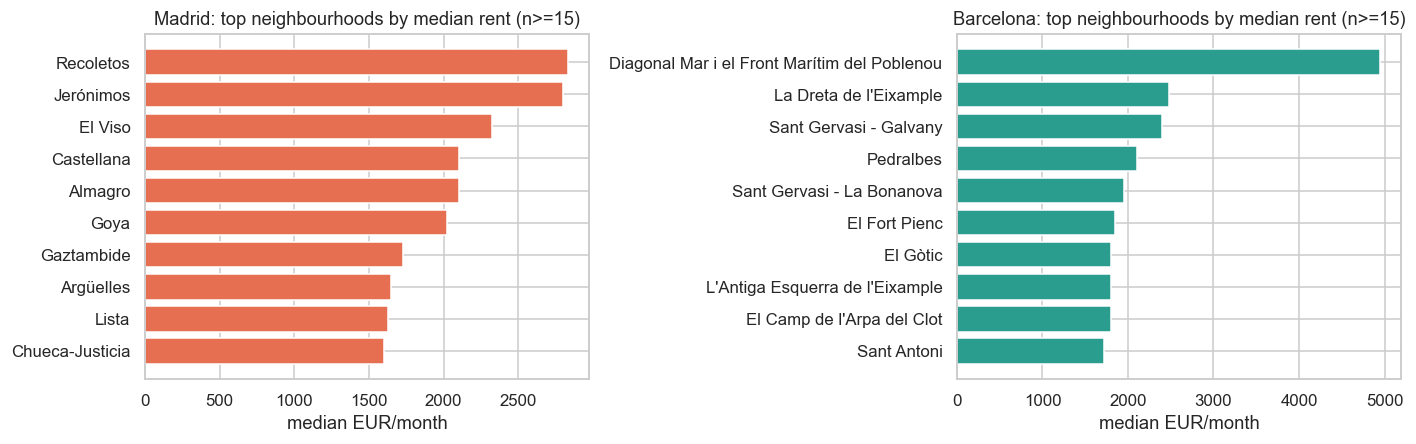

In [3]:
# rent varies hugely by neighbourhood — the signal we unlocked from `title`
top = (df.groupby(["city","neighborhood"])["rent_eur_month"]
         .agg(["median","size"]).query("size>=15").reset_index())
fig, ax = plt.subplots(1, 2, figsize=(13,4.2))
for a,(cty,col) in zip(ax, [("Madrid","#e76f51"),("Barcelona","#2a9d8f")]):
    d = top[top.city==cty].nlargest(10,"median").sort_values("median")
    a.barh(d["neighborhood"], d["median"], color=col)
    a.set_title(f"{cty}: top neighbourhoods by median rent (n>=15)")
    a.set_xlabel("median EUR/month")
plt.tight_layout(); plt.savefig(f"{FIG}/04_rent_by_neighborhood.png", bbox_inches="tight"); plt.show()

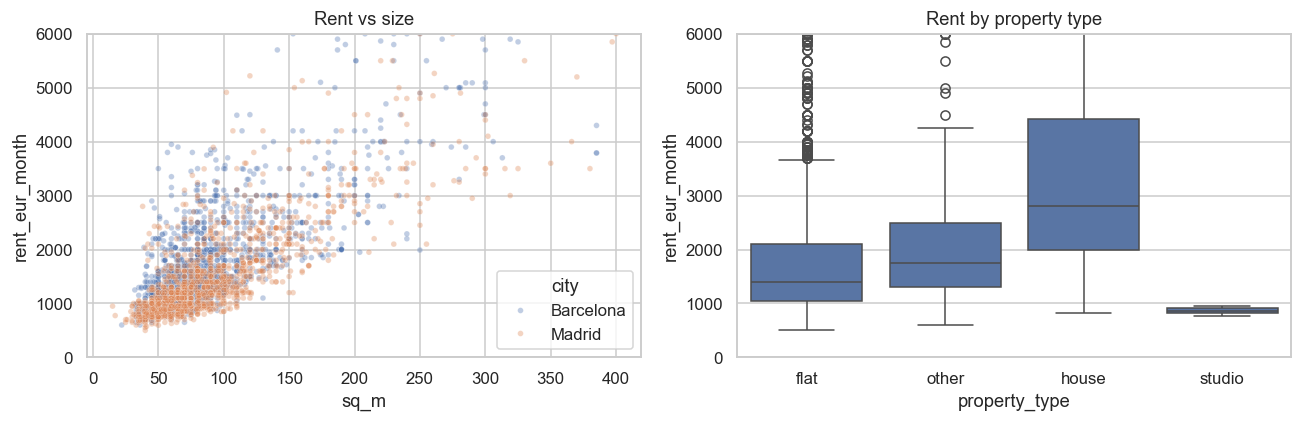

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(data=df, x="sq_m", y="rent_eur_month", hue="city", alpha=.35, s=14, ax=ax[0])
ax[0].set_title("Rent vs size"); ax[0].set_ylim(0,6000)
sns.boxplot(data=df, x="property_type", y="rent_eur_month",
            order=df.property_type.value_counts().index, ax=ax[1])
ax[1].set_title("Rent by property type"); ax[1].set_ylim(0,6000)
plt.tight_layout(); plt.savefig(f"{FIG}/05_rent_size_type.png", bbox_inches="tight"); plt.show()

## 2. Train & evaluate (Ridge baseline vs XGBoost)

In [5]:
results = train_and_evaluate(scope="city", verbose=False)
rows=[]
for m in ["ridge","xgboost"]:
    o=results[m]["test"]["overall"]
    rows.append({"model":m, "CV_MAE":results[m]["cv_MAE_eur"], **o})
pd.DataFrame(rows).set_index("model")

,CV_MAE,MAE_eur,RMSE_eur,MAPE_pct,R2
model,,,,,
ridge,455.6,497.5,867.5,23.2,0.520
xgboost,421.5,443.3,755.4,20.4,0.636


**Read-out.** XGBoost wins (lower MAE/MAPE, higher R²). Both are honest about the data's limits —
~21% MAPE means typical predictions land within ~€450/mo of actual. Good enough to *rank* properties
and feed the rent/Airbnb/sell comparison; not a precise valuation tool yet.

In [6]:
# per-city test metrics for the best model
best = results["best_model"]
pd.DataFrame(results[best]["test"]).T

,MAE_eur,RMSE_eur,MAPE_pct,R2
overall,443.3,755.4,20.4,0.636
Madrid,335.7,555.2,17.8,0.724
Barcelona,552.9,915.4,23.0,0.558


## 3. What drives rent (permutation importance)

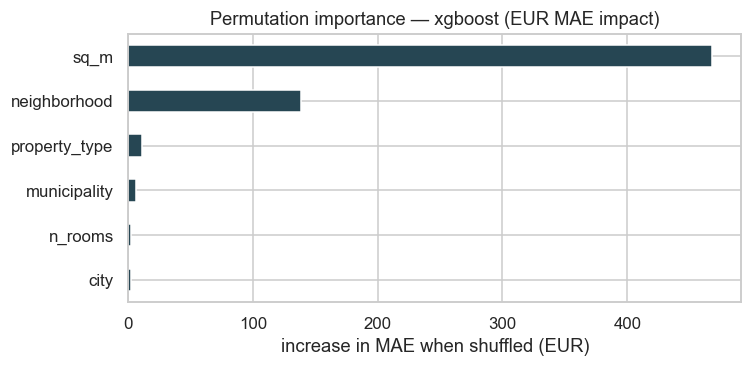

Size dominates; the title-derived NEIGHBOURHOOD is the clear #2 driver.


In [7]:
imp = pd.Series(results["permutation_importance"]).sort_values()
fig, ax = plt.subplots(figsize=(7,3.5))
imp.plot.barh(ax=ax, color="#264653")
ax.set_title(f"Permutation importance — {best} (EUR MAE impact)")
ax.set_xlabel("increase in MAE when shuffled (EUR)")
plt.tight_layout(); plt.savefig(f"{FIG}/06_feature_importance.png", bbox_inches="tight"); plt.show()
print("Size dominates; the title-derived NEIGHBOURHOOD is the clear #2 driver.")

## 4. Residual diagnostics

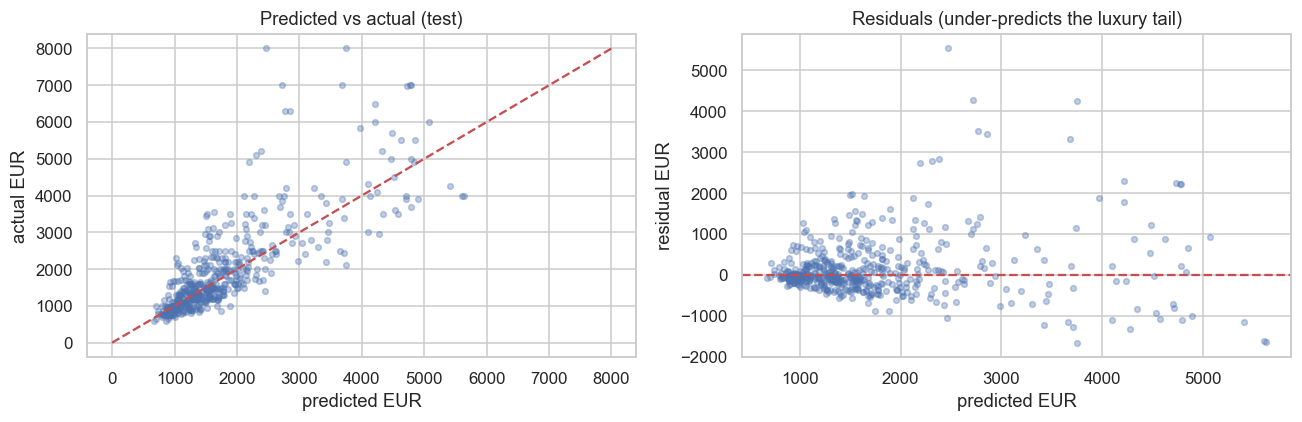

In [8]:
from sklearn.model_selection import train_test_split
import joblib
mdl = joblib.load("../models/rent_model.pkl")
X, y = df[FEATURES], df["rent_eur_month"]
_, Xte, _, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X["city"])
pred = mdl.predict(Xte); resid = yte - pred
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(pred, yte, alpha=.35, s=14); lim=[0, max(yte.max(),pred.max())]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlabel("predicted EUR"); ax[0].set_ylabel("actual EUR")
ax[0].set_title("Predicted vs actual (test)")
ax[1].scatter(pred, resid, alpha=.35, s=14); ax[1].axhline(0, color="r", ls="--")
ax[1].set_xlabel("predicted EUR"); ax[1].set_ylabel("residual EUR")
ax[1].set_title("Residuals (under-predicts the luxury tail)")
plt.tight_layout(); plt.savefig(f"{FIG}/07_residuals.png", bbox_inches="tight"); plt.show()

## 5. Using the model — example predictions

In [9]:
examples = [
    dict(city="Madrid",    sq_m=80,  n_rooms=2, property_type="flat",  neighborhood="Trafalgar"),
    dict(city="Madrid",    sq_m=45,  n_rooms=1, property_type="studio",neighborhood="Lavapiés-Embajadores"),
    dict(city="Barcelona", sq_m=90,  n_rooms=3, property_type="flat",  neighborhood="La Dreta de l'Eixample"),
    dict(city="Barcelona", sq_m=60,  n_rooms=2, property_type="flat",  neighborhood="El Raval"),
]
pd.DataFrame([{**e, **predict_rent(**e)} for e in examples])

,city,sq_m,n_rooms,property_type,neighborhood,monthly_eur,annual_eur
0,Madrid,80,2,flat,Trafalgar,1723,20680
1,Madrid,45,1,studio,Lavapiés-Embajadores,956,11470
2,Barcelona,90,3,flat,La Dreta de l'Eixample,2102,25224
3,Barcelona,60,2,flat,El Raval,1221,14652


## 6. Next steps

1. **Quantify the 2022 vintage gap** — when fresh data arrives (idealista API or scrape), call
   `model.evaluate_against_live(df)`; `mean_signed_error` shows how far current rents have moved.
2. **Add features that matter** — bathrooms, amenities, floor, condition (need richer scrape/API).
3. **Geocode `street`** (68% coverage) → distance-to-centre, transit proximity.
4. **Optional** — enrich with neighbourhood median EUR/m2 from the recent *sale* datasets.
5. Feed `predict_rent` output (monthly + annual) into the rent/Airbnb/sell comparison layer.
